In [17]:
from pathlib import Path

import kagglehub
import pandas as pd
import os
from os import listdir
from os.path import isfile, join
from torch.utils.data import Dataset
from PIL import Image
from src.helpers import print_data_folder_structure, plot_img, visual_exploration


In [2]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [3]:
print_data_folder_structure(dataset_path, 1)

cifar-10/
├── sampleSubmission.csv
├── test.7z
├── train.7z
├── trainLabels.csv
├── test/
└── train/


In [4]:
labels_df = pd.read_csv(labels_path)

In [5]:
files = [(int(Path(join(train_path, f)).stem), f) for f in listdir(train_path) if isfile(join(train_path, f))]

In [6]:
files_df = pd.DataFrame(files, columns=["id", "file_name"])

In [7]:
cifar_pd = pd.merge(labels_df, files_df, on='id', how='inner')

In [8]:
all_labels = cifar_pd['label'].drop_duplicates().reset_index()
all_labels['target'] = all_labels.index
all_labels = all_labels.drop(columns=['index'])

In [9]:
cifar_pd = pd.merge(cifar_pd, all_labels, on='label', how='left')

In [10]:
cifar_pd

,id,label,file_name,target
0,1,frog,1.png,0
1,2,truck,2.png,1
2,3,truck,3.png,1
3,4,deer,4.png,2
4,5,automobile,5.png,3
...,...,...,...,...
49995,49996,bird,49996.png,4
49996,49997,frog,49997.png,0
49997,49998,truck,49998.png,1
49998,49999,automobile,49999.png,3


In [11]:
all_target_labels = [
    'frog',
    'bird',
    'ship',
    'cat'
]
filtered_cifar = cifar_pd[cifar_pd['label'].isin(all_target_labels)]

In [12]:
class TmpCifarDataset(Dataset):
    def __init__(self, train_lib_dir, df, transform=None):
        self.train_lib_dir = train_lib_dir
        self.df = df
        self.transform = transform
        self.labels = df['label']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        image = self.retrieve_image(item)
        if self.transform is not None:
            image = self.transform(image)
        return image, item['target']

    def retrieve_image(self, item):
        image_path = os.path.join(self.train_lib_dir, item['file_name'])
        with Image.open(image_path) as img:
            image = img.convert("RGB")
        return image

    def get_label_description(self, idx):
        return self.df.iloc[idx]['label']

In [21]:
dataset = TmpCifarDataset(train_path, filtered_cifar)
full_dataset = TmpCifarDataset(train_path, cifar_pd)

In [14]:
print(f'Length of the dataset: {len(dataset)}')

Length of the dataset: 20000


Description: bird
Image shape: (32, 32)



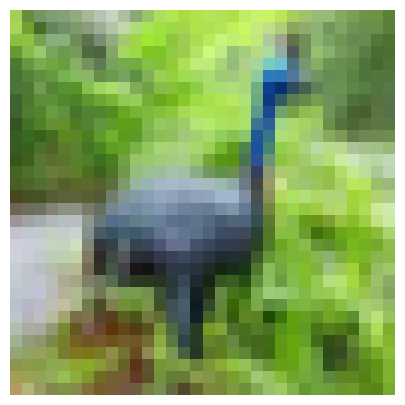

In [15]:
# Look at a sample to check it's working correctly
sel_idx = 2
img, label = dataset[sel_idx]

# Visualize the image
plot_img(img)

# Print its description
print(f'Description: {dataset.get_label_description(sel_idx)}')

# Print its shape
print(f'Image shape: {img.size}\n')  # PIL image size is (width, height)

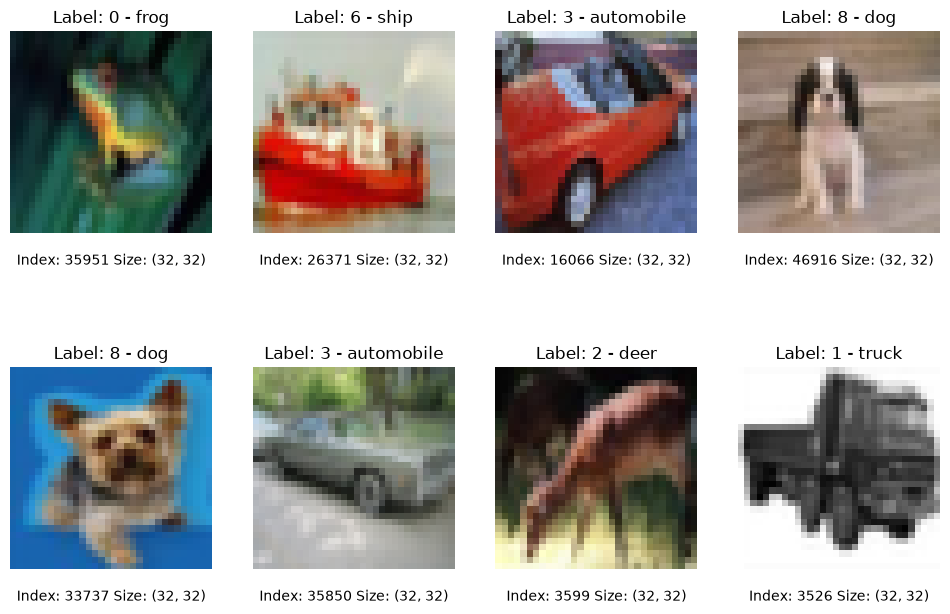

In [25]:
visual_exploration(full_dataset, num_rows=2, num_cols=4)